# Analyse de sensibilité — terrainSA

Ce notebook repart du fichier `dataset_metamodel.csv` produit par les simulations `terrainSA`.

## Plan du notebook

### Partie I — Données et paramètres
- Chargement du dataset `terrainSA`.
- Reconstruction des 26 paramètres agricoles du plan SMT.

### Partie II — Analyses directes par ANOVA/Kruskal
- Analyse à un facteur avec R2 par paramètre.
- Analyse à deux facteurs avec R2 global, additif et interaction.
- Matrices de R2 pour les couples de paramètres.

### Partie III — Métamodèles compatibles avec le plan SMT
- PCE creux entraîné uniquement sur les points faisables du plan SMT.
- Estimation analytique des indices de Sobol depuis les coefficients du PCE.
- Gaussian Process entraîné sur un sous-échantillon faisable comme référence probabiliste.

### Partie IV — Comparaison et sélection des métamodèles prédictifs
- Comparaison ExtraTrees, XGBoost et Gaussian Process.
- Sélection automatique du meilleur modèle par sortie selon le Q2 test.

### Partie V — Indices globaux complémentaires via le meilleur métamodèle
- Indices empiriques de type pick-freeze sur la distribution observée du plan SMT.
- Valeurs de Shapley associées à chaque paramètre.

Les résultats sont écrits dans le dossier `analysis/terrainSA_results`.


In [3]:
# ============================================================
# 1. Imports et configuration
# ============================================================

from pathlib import Path
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy import stats

try:
    import openturns as ot
    OPENTURNS_AVAILABLE = True
    ot.Log.Show(ot.Log.NONE)
except Exception as exc:
    ot = None
    OPENTURNS_AVAILABLE = False
    print("OpenTURNS indisponible, la section PCE creux sera ignorée :", exc)

from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    print("XGBoost indisponible, comparaison limitée à ExtraTrees et Gaussian Process :", exc)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("/Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA")
ANALYSIS_DIR = PROJECT_ROOT / "analysis"
OUTPUT_DIR = ANALYSIS_DIR / "terrainSA_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Tu peux indiquer ici soit le fichier CSV directement, soit le dossier de logs terrainSA.
DATASET_FILENAME = "dataset_metamodel.csv"
LOG_TERRAINSA_DIR = PROJECT_ROOT / "simulations" / "log_terrainSA"

DATASET_CANDIDATES = [
    LOG_TERRAINSA_DIR,
    LOG_TERRAINSA_DIR / DATASET_FILENAME,
    PROJECT_ROOT / "data" / DATASET_FILENAME,
    Path("/tmp/maelia_smt_terrainSA_xml") / DATASET_FILENAME,
    PROJECT_ROOT / "data" / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / "dataset_metamodel_terrainSA.csv",
    ANALYSIS_DIR / DATASET_FILENAME,
]

OUTPUT_COLS = ["N_lixi", "dCorg", "rdt"]
RANDOM_SEED = 42

# Réglages statistiques
N_QUANTILE_BINS = 4
MIN_GROUP_SIZE = 5
MIN_TOTAL_N = 30
TOP_TWO_FACTOR_PAIRS_TO_DISPLAY = 30

# Réglages métamodèle / Monte Carlo
TEST_SIZE = 0.25
N_TREES = 400
XGB_N_ESTIMATORS = 600
GP_MAX_TRAIN = 1500
SOBOL_N_MC = 2500
SHAPLEY_N_MC = 700
SHAPLEY_N_PERM = 64
SHAPLEY_N_INNER = 3

# Réglages PCE creux / GP compatibles SMT
PCE_DEGREE = 2
PCE_MAX_TERMS = 90
PCE_MAX_TRAIN = 8000
GP_SMT_MAX_TRAIN = 1500

print("Dossier d'analyse :", ANALYSIS_DIR)
print("Dossier de sortie :", OUTPUT_DIR)


Dossier d'analyse : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis
Dossier de sortie : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results


In [4]:
# ============================================================
# 2. Chargement du dataset terrainSA
# ============================================================

def resolve_dataset_path(candidates, filename=DATASET_FILENAME):
    checked = []
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        checked.append(candidate)

        if candidate.is_file():
            return candidate, checked

        if candidate.is_dir():
            direct_csv = candidate / filename
            checked.append(direct_csv)
            if direct_csv.is_file():
                return direct_csv, checked

            nested = sorted(candidate.rglob(filename))
            checked.extend(nested[:5])
            if nested:
                return nested[0], checked

    return None, checked


DATASET_PATH, checked_dataset_paths = resolve_dataset_path(DATASET_CANDIDATES)

if DATASET_PATH is None:
    print("Aucun dataset terrainSA trouvé. Chemins testés :")
    for candidate in checked_dataset_paths:
        print(" -", candidate)
    raise FileNotFoundError(
        "Exécuter d'abord le notebook de simulation terrainSA jusqu'à l'export "
        "de dataset_metamodel.csv, ou renseigner LOG_TERRAINSA_DIR avec le dossier "
        "qui contient ce fichier."
    )

df_raw = pd.read_csv(DATASET_PATH)
print("Dataset chargé :", DATASET_PATH)
print("Dossier de logs :", DATASET_PATH.parent)
print("Dimensions :", df_raw.shape)
display(df_raw.head())

missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]
if missing_outputs:
    raise ValueError(f"Sorties absentes du dataset : {missing_outputs}")


Dataset chargé : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/simulations/log_terrainSA/dataset_metamodel.csv
Dossier de logs : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/simulations/log_terrainSA
Dimensions : (10000, 33)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_23,feat_24,feat_25,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,...,55.000000,55.0,55.0,0,0,2.952,-226.304,4.495,0,beauce_5_sa_000
1,2.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,...,27.061441,55.0,55.0,0,0,2.436,-297.342,4.635,1,beauce_5_sa_001
2,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.0,55.0,0,0,2.404,-234.062,4.615,2,beauce_5_sa_002
3,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,...,55.000000,55.0,55.0,0,0,2.630,-215.032,4.475,3,beauce_5_sa_003
4,1.0,1.0,1.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,...,55.000000,55.0,55.0,0,0,2.706,-258.598,4.630,4,beauce_5_sa_004


In [5]:
# ============================================================
# 3. Reconstruction des paramètres agricoles
# ============================================================

# Ordre réel des colonnes feat_0...feat_25 après correction SMT/ADSG.
AGRI_FEATURES = ['n_ferti', 'has_prepa', 'nb_prepa', 'prepa_1', 'nb_f1', 'type_f1_1', 'nb_f2', 'type_f2_1', 'nb_f3', 'type_f3_1', 'prepa_2', 'type_f1_2', 'type_f2_2', 'type_f3_2', 'Date_Semis', 'Delta_PREPA_Semis', 'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2']

AGRI_CATEGORICAL = ['n_ferti', 'has_prepa', 'nb_prepa', 'prepa_1', 'nb_f1', 'type_f1_1', 'nb_f2', 'type_f2_1', 'nb_f3', 'type_f3_1', 'prepa_2', 'type_f1_2', 'type_f2_2', 'type_f3_2']
AGRI_CONTINUOUS = [c for c in AGRI_FEATURES if c not in AGRI_CATEGORICAL]

feat_cols = [f"feat_{i}" for i in range(26)]
if all(col in df_raw.columns for col in feat_cols):
    X_params = df_raw[feat_cols].copy()
    X_params.columns = AGRI_FEATURES
elif df_raw.shape[1] >= 26:
    X_params = df_raw.iloc[:, :26].copy()
    X_params.columns = AGRI_FEATURES
else:
    raise ValueError("Le dataset doit contenir 26 colonnes de paramètres agricoles.")

df = pd.concat([X_params, df_raw[OUTPUT_COLS]], axis=1)

if "point_idx" in df_raw.columns:
    df["point_idx"] = df_raw["point_idx"]
if "parcelle" in df_raw.columns:
    df["parcelle"] = df_raw["parcelle"]

for col in ["Milieu (Climat)", "Milieu (Sol)", "zone", "sol_type", "zone_meteo"]:
    if col in df_raw.columns:
        df[col] = df_raw[col]

print("Paramètres agricoles :", len(AGRI_FEATURES))
print("Paramètres continus :", AGRI_CONTINUOUS)
print("Sorties :", OUTPUT_COLS)
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Paramètres agricoles : 26
Paramètres continus : ['Date_Semis', 'Delta_PREPA_Semis', 'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2']
Sorties : ['N_lixi', 'dCorg', 'rdt']


,n_ferti,has_prepa,nb_prepa,prepa_1,nb_f1,type_f1_1,nb_f2,type_f2_1,nb_f3,type_f3_1,...,Date_Recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2,N_lixi,dCorg,rdt
0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,...,365.768692,96.647952,55.000000,55.000000,55.000000,55.0,55.0,2.952,-226.304,4.495
1,2.0,1.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,0.0,...,375.618684,93.774823,42.365041,44.735456,27.061441,55.0,55.0,2.436,-297.342,4.635
2,0.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,360.891856,55.000000,55.000000,55.000000,55.000000,55.0,55.0,2.404,-234.062,4.615
3,1.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,...,344.995088,47.735087,74.751692,55.000000,55.000000,55.0,55.0,2.630,-215.032,4.475
4,1.0,1.0,1.0,3.0,0.0,2.0,0.0,0.0,0.0,0.0,...,380.433896,28.880062,55.000000,55.000000,55.000000,55.0,55.0,2.706,-258.598,4.630


## Partie II.A — Analyse directe à un facteur

Pour chaque paramètre et chaque sortie :

- les variables continues sont discrétisées en quartiles ;
- les variables discrètes/catégorielles sont traitées comme facteurs ;
- le test utilisé est ANOVA si les hypothèses de normalité intra-groupe et d'homoscédasticité sont raisonnables, Kruskal sinon ;
- le `R2_parametre` est calculé comme la part de variance expliquée par les moyennes de groupes : `SS_between / SS_total`.


In [14]:
# ============================================================
# 4. Fonctions ANOVA/Kruskal à un facteur
# ============================================================

def factorize_for_tests(series, feature_name):
    s = series.copy()
    if feature_name in AGRI_CONTINUOUS:
        try:
            q = pd.qcut(s.astype(float), q=N_QUANTILE_BINS, duplicates="drop")
            return q.astype(str).replace("nan", np.nan)
        except Exception:
            return pd.Series(np.nan, index=s.index)
    return s.astype("object").where(s.notna(), "inactif").astype(str)


def grouped_arrays(y, groups):
    data = pd.DataFrame({"y": y, "group": groups}).dropna()
    counts = data["group"].value_counts()
    valid = counts[counts >= MIN_GROUP_SIZE].index
    data = data[data["group"].isin(valid)]
    arrays = [g["y"].to_numpy() for _, g in data.groupby("group", observed=True)]
    return data, arrays


def test_assumptions(arrays):
    if len(arrays) < 2:
        return False, np.nan, np.nan

    normal_pvals = []
    rng = np.random.default_rng(RANDOM_SEED)
    for arr in arrays:
        if len(arr) < 3:
            return False, np.nan, np.nan
        sample = arr
        if len(sample) > 500:
            sample = rng.choice(sample, size=500, replace=False)
        try:
            normal_pvals.append(stats.shapiro(sample).pvalue)
        except Exception:
            normal_pvals.append(0.0)

    try:
        levene_p = stats.levene(*arrays, center="median").pvalue
    except Exception:
        levene_p = 0.0

    normal_p = float(np.nanmin(normal_pvals))
    use_anova = normal_p > 0.01 and levene_p > 0.01
    return use_anova, normal_p, float(levene_p)


def grouped_r2(data):
    y = data["y"].to_numpy()
    if len(y) < 2:
        return np.nan
    ybar = np.mean(y)
    ss_total = np.sum((y - ybar) ** 2)
    if ss_total <= 0:
        return np.nan
    ss_between = 0.0
    for _, g in data.groupby("group", observed=True):
        ss_between += len(g) * (g["y"].mean() - ybar) ** 2
    return float(ss_between / ss_total)


def one_factor_analysis(df, output_col):
    rows = []
    y = df[output_col]
    for feature in AGRI_FEATURES:
        groups = factorize_for_tests(df[feature], feature)
        data, arrays = grouped_arrays(y, groups)
        if len(data) < MIN_TOTAL_N or len(arrays) < 2:
            rows.append({
                "sortie": output_col, "parametre": feature, "test": "non_testable",
                "p_value": np.nan, "R2_parametre": np.nan,
                "n": len(data), "n_groupes": len(arrays),
                "normalite_min_p": np.nan, "levene_p": np.nan,
            })
            continue

        use_anova, normal_p, levene_p = test_assumptions(arrays)
        if use_anova:
            stat = stats.f_oneway(*arrays)
            test_name = "ANOVA"
        else:
            stat = stats.kruskal(*arrays)
            test_name = "Kruskal"

        rows.append({
            "sortie": output_col,
            "parametre": feature,
            "test": test_name,
            "statistique": float(stat.statistic),
            "p_value": float(stat.pvalue),
            "R2_parametre": grouped_r2(data),
            "n": len(data),
            "n_groupes": len(arrays),
            "normalite_min_p": normal_p,
            "levene_p": levene_p,
        })
    return pd.DataFrame(rows)


In [15]:
# ============================================================
# 5. Exécution un facteur
# ============================================================

anova_1 = pd.concat([one_factor_analysis(df, y) for y in OUTPUT_COLS], ignore_index=True)
anova_1 = anova_1.sort_values(["sortie", "R2_parametre"], ascending=[True, False])
anova_1.to_csv(OUTPUT_DIR / "anova_kruskal_1facteur.csv", index=False)

anova_1_r2_sum = (
    anova_1.groupby("sortie", as_index=False)["R2_parametre"]
    .sum(min_count=1)
    .rename(columns={"R2_parametre": "somme_R2_1facteur"})
)
anova_1_r2_sum.to_csv(OUTPUT_DIR / "anova_1facteur_somme_R2.csv", index=False)

display(anova_1.groupby("sortie").head(12))
print("Somme des R2 - ANOVA/Kruskal un facteur :")
display(anova_1_r2_sum)
print("Écrit :", OUTPUT_DIR / "anova_kruskal_1facteur.csv")
print("Écrit :", OUTPUT_DIR / "anova_1facteur_somme_R2.csv")


,sortie,parametre,test,statistique,p_value,R2_parametre,n,n_groupes,normalite_min_p,levene_p
14,N_lixi,Date_Semis,Kruskal,4801.856699,0.000000e+00,0.463154,10000,4,3.160153e-08,5.110412e-95
15,N_lixi,Delta_PREPA_Semis,Kruskal,2014.012815,0.000000e+00,0.213910,9997,3,1.904469e-13,1.359257e-02
1,N_lixi,has_prepa,Kruskal,1476.775740,0.000000e+00,0.145158,10000,2,4.611592e-09,6.915381e-03
3,N_lixi,prepa_1,Kruskal,1182.966347,3.638435e-256,0.117770,10000,4,9.280777e-10,9.782279e-01
19,N_lixi,Date_Recolte,Kruskal,717.957129,2.680299e-155,0.057183,10000,4,5.662300e-18,0.000000e+00
10,N_lixi,prepa_2,Kruskal,513.939913,4.545742e-111,0.052171,10000,4,8.016237e-10,9.179984e-03
2,N_lixi,nb_prepa,Kruskal,513.268646,1.233262e-113,0.052062,10000,2,1.163931e-06,1.318944e-03
16,N_lixi,Date_F1,Kruskal,7.650505,5.381487e-02,0.000703,10000,4,3.479739e-07,7.583168e-01
5,N_lixi,type_f1_1,Kruskal,3.921747,2.700390e-01,0.000490,10000,4,1.373369e-07,2.060309e-01
17,N_lixi,Date_F2,Kruskal,3.183409,7.438936e-02,0.000426,10000,2,3.845776e-07,3.078836e-01


Somme des R2 - ANOVA/Kruskal un facteur :


,sortie,somme_R2_1facteur
0,N_lixi,1.105455
1,dCorg,0.944232
2,rdt,1.274588


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_kruskal_1facteur.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_1facteur_somme_R2.csv


## Partie II.B — Analyse directe à deux facteurs

Pour chaque paire de paramètres, on ajuste deux modèles linéaires sur facteurs discrétisés :

- modèle additif : `A + B` ;
- modèle saturé par cellules : `A:B`, qui contient les effets principaux et leur interaction.

On rapporte :

- `R2_A` et `R2_B` : R2 des analyses à un facteur ;
- `R2_additif` : variance expliquée par les deux facteurs sans interaction ;
- `R2_interaction` : gain de R2 apporté par les cellules `A:B` ;
- `R2_global` : R2 du modèle à deux facteurs complet.

Si les distributions sont très non normales, cette approche doit être lue comme une ANOVA descriptive sur groupes, pas comme une preuve paramétrique stricte.


In [16]:
# ============================================================
# 6. Fonctions deux facteurs
# ============================================================

def ols_r2_and_pvalue(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    ok = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y = y[ok]
    X = X[ok]
    n = len(y)
    if n < MIN_TOTAL_N:
        return np.nan, np.nan, np.nan, np.nan

    X_design = np.column_stack([np.ones(n), X])
    beta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
    yhat = X_design @ beta
    sse = np.sum((y - yhat) ** 2)
    sst = np.sum((y - np.mean(y)) ** 2)
    if sst <= 0:
        return np.nan, np.nan, np.nan, np.nan

    rank = np.linalg.matrix_rank(X_design)
    df_model = rank - 1
    df_resid = n - rank
    r2 = 1.0 - sse / sst
    if df_model <= 0 or df_resid <= 0 or sse <= 0:
        pval = np.nan
        fstat = np.nan
    else:
        fstat = ((sst - sse) / df_model) / (sse / df_resid)
        pval = float(stats.f.sf(fstat, df_model, df_resid))
    return float(r2), pval, float(df_model), float(df_resid)


def two_factor_analysis(df, output_col):
    one_r2 = (
        anova_1[anova_1["sortie"] == output_col]
        .set_index("parametre")["R2_parametre"]
        .to_dict()
    )

    rows = []
    y = df[output_col]
    for a, b in itertools.combinations(AGRI_FEATURES, 2):
        fa = factorize_for_tests(df[a], a)
        fb = factorize_for_tests(df[b], b)
        data = pd.DataFrame({"y": y, "A": fa, "B": fb}).dropna()

        if len(data) < MIN_TOTAL_N:
            continue

        data["cell"] = data["A"].astype(str) + " × " + data["B"].astype(str)
        cell_counts = data["cell"].value_counts()
        valid_cells = cell_counts[cell_counts >= MIN_GROUP_SIZE].index
        data = data[data["cell"].isin(valid_cells)].copy()
        if data["A"].nunique() < 2 or data["B"].nunique() < 2 or data["cell"].nunique() < 2:
            continue

        X_add = pd.get_dummies(data[["A", "B"]].astype(str), drop_first=True)
        X_full = pd.get_dummies(data["cell"].astype(str), drop_first=True)

        r2_add, p_add, _, _ = ols_r2_and_pvalue(data["y"], X_add)
        r2_full, p_full, df_model, df_resid = ols_r2_and_pvalue(data["y"], X_full)

        rows.append({
            "sortie": output_col,
            "parametre_A": a,
            "parametre_B": b,
            "R2_A": one_r2.get(a, np.nan),
            "R2_B": one_r2.get(b, np.nan),
            "R2_additif": r2_add,
            "R2_interaction": r2_full - r2_add if pd.notna(r2_full) and pd.notna(r2_add) else np.nan,
            "R2_global": r2_full,
            "p_value_additif": p_add,
            "p_value_global": p_full,
            "n": len(data),
            "n_A": data["A"].nunique(),
            "n_B": data["B"].nunique(),
            "n_cellules": data["cell"].nunique(),
            "df_model_global": df_model,
            "df_resid_global": df_resid,
        })

    return pd.DataFrame(rows)


In [17]:
# ============================================================
# 7. Exécution deux facteurs
# ============================================================

anova_2 = pd.concat([two_factor_analysis(df, y) for y in OUTPUT_COLS], ignore_index=True)
anova_2 = anova_2.sort_values(["sortie", "R2_global"], ascending=[True, False])
anova_2.to_csv(OUTPUT_DIR / "anova_2facteurs.csv", index=False)

anova_2_r2_sum = (
    anova_2.groupby("sortie", as_index=False)
    .agg(
        somme_R2_additif=("R2_additif", "sum"),
        somme_R2_interaction=("R2_interaction", "sum"),
        somme_R2_global=("R2_global", "sum"),
    )
)
anova_2_r2_sum.to_csv(OUTPUT_DIR / "anova_2facteurs_somme_R2.csv", index=False)

def build_two_factor_matrix(anova_2, output_col, value_col="R2_global"):
    matrix = pd.DataFrame(np.nan, index=AGRI_FEATURES, columns=AGRI_FEATURES, dtype=float)
    sub = anova_2[anova_2["sortie"] == output_col]
    for row in sub.itertuples(index=False):
        a = row.parametre_A
        b = row.parametre_B
        value = getattr(row, value_col)
        matrix.loc[a, b] = value
        matrix.loc[b, a] = value
    for feature in AGRI_FEATURES:
        matrix.loc[feature, feature] = 0.0
    return matrix

anova_2_matrices = {}
for output in OUTPUT_COLS:
    matrix_global = build_two_factor_matrix(anova_2, output, "R2_global")
    matrix_interaction = build_two_factor_matrix(anova_2, output, "R2_interaction")
    anova_2_matrices[(output, "R2_global")] = matrix_global
    anova_2_matrices[(output, "R2_interaction")] = matrix_interaction
    matrix_global.to_csv(OUTPUT_DIR / f"anova_2facteurs_matrice_R2_global_{output}.csv")
    matrix_interaction.to_csv(OUTPUT_DIR / f"anova_2facteurs_matrice_R2_interaction_{output}.csv")

display(anova_2.groupby("sortie").head(TOP_TWO_FACTOR_PAIRS_TO_DISPLAY))
print("Somme des R2 - ANOVA deux facteurs :")
display(anova_2_r2_sum)

for output in OUTPUT_COLS:
    print(f"Matrice ANOVA deux facteurs - R2_global - {output}")
    display(anova_2_matrices[(output, "R2_global")].round(3))
    print(f"Matrice ANOVA deux facteurs - R2_interaction - {output}")
    display(anova_2_matrices[(output, "R2_interaction")].round(3))

print("Écrit :", OUTPUT_DIR / "anova_2facteurs.csv")
print("Écrit :", OUTPUT_DIR / "anova_2facteurs_somme_R2.csv")


,sortie,parametre_A,parametre_B,R2_A,R2_B,R2_additif,R2_interaction,R2_global,p_value_additif,p_value_global,n,n_A,n_B,n_cellules,df_model_global,df_resid_global
259,N_lixi,Date_Semis,Delta_PREPA_Semis,0.463154,2.139098e-01,0.681934,0.011865,0.693799,0.0,0.0,9997,4,3,12,11.0,9985.0
263,N_lixi,Date_Semis,Date_Recolte,0.463154,5.718301e-02,0.521919,0.101685,0.623603,0.0,0.0,10000,4,4,16,15.0,9984.0
37,N_lixi,has_prepa,Date_Semis,0.145158,4.631544e-01,0.614350,0.003620,0.617971,0.0,0.0,10000,2,4,8,7.0,9992.0
82,N_lixi,prepa_1,Date_Semis,0.117770,4.631544e-01,0.582889,0.002838,0.585726,0.0,0.0,10000,4,4,16,15.0,9984.0
208,N_lixi,prepa_2,Date_Semis,0.052171,4.631544e-01,0.517649,0.001092,0.518741,0.0,0.0,10000,4,4,16,15.0,9984.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,rdt,Delta_PREPA_Semis,Date_F2,0.342306,7.672320e-05,0.342317,0.000127,0.342444,0.0,0.0,9997,3,2,6,5.0,9991.0
922,rdt,Delta_PREPA_Semis,Date_F3,0.342306,4.218163e-06,0.342307,0.000095,0.342402,0.0,0.0,9997,3,2,6,5.0,9991.0
929,rdt,Delta_PREPA_Semis,Dose_F3_2,0.342306,1.448926e-04,0.342367,0.000031,0.342398,0.0,0.0,9997,3,2,6,5.0,9991.0
925,rdt,Delta_PREPA_Semis,Dose_F1_2,0.342306,4.953964e-08,0.342308,0.000079,0.342388,0.0,0.0,9997,3,2,6,5.0,9991.0


Somme des R2 - ANOVA deux facteurs :


,sortie,somme_R2_additif,somme_R2_interaction,somme_R2_global
0,N_lixi,26.908156,0.231992,27.140147
1,dCorg,23.590833,0.118138,23.708971
2,rdt,30.587499,0.333957,30.921456


Matrice ANOVA deux facteurs - R2_global - N_lixi


,n_ferti,has_prepa,nb_prepa,prepa_1,nb_f1,type_f1_1,nb_f2,type_f2_1,nb_f3,type_f3_1,...,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2
n_ferti,0.000,0.145,0.052,0.119,0.000,0.001,0.001,0.001,0.000,0.001,...,0.001,0.001,0.000,0.058,0.002,0.000,0.001,0.000,0.000,0.000
has_prepa,0.145,0.000,0.145,0.145,0.145,0.146,0.145,0.146,0.145,0.146,...,0.146,0.146,0.145,0.203,0.146,0.145,0.146,0.145,0.145,0.145
nb_prepa,0.052,0.145,0.000,0.118,0.052,0.053,0.052,0.053,0.052,0.052,...,0.053,0.053,0.052,0.108,0.053,0.052,0.053,0.052,0.052,0.053
prepa_1,0.119,0.145,0.118,0.000,0.118,0.119,0.118,0.119,0.118,0.119,...,0.120,0.118,0.118,0.176,0.119,0.118,0.119,0.118,0.118,0.118
nb_f1,0.000,0.145,0.052,0.118,0.000,0.001,0.000,0.000,0.000,0.000,...,0.001,0.001,0.000,0.057,0.000,0.000,0.001,0.000,0.000,0.000
type_f1_1,0.001,0.146,0.053,0.119,0.001,0.000,0.001,0.002,0.001,0.002,...,0.003,0.001,0.001,0.058,0.001,0.001,0.001,0.001,0.001,0.001
nb_f2,0.001,0.145,0.052,0.118,0.000,0.001,0.000,0.000,0.000,0.000,...,0.001,0.000,0.000,0.058,0.001,0.000,0.000,0.000,0.000,0.000
type_f2_1,0.001,0.146,0.053,0.119,0.000,0.002,0.000,0.000,0.001,0.001,...,0.001,0.001,0.001,0.058,0.001,0.000,0.001,0.000,0.001,0.001
nb_f3,0.000,0.145,0.052,0.118,0.000,0.001,0.000,0.001,0.000,0.001,...,0.001,0.001,0.000,0.058,0.001,0.000,0.001,0.000,0.001,0.000
type_f3_1,0.001,0.146,0.052,0.119,0.000,0.002,0.000,0.001,0.001,0.000,...,0.002,0.001,0.000,0.058,0.002,0.001,0.001,0.001,0.001,0.001


...

Matrice ANOVA deux facteurs - R2_global - rdt


,n_ferti,has_prepa,nb_prepa,prepa_1,nb_f1,type_f1_1,nb_f2,type_f2_1,nb_f3,type_f3_1,...,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2
n_ferti,0.000,0.245,0.090,0.197,0.000,0.002,0.001,0.001,0.000,0.001,...,0.001,0.001,0.000,0.170,0.001,0.000,0.001,0.000,0.000,0.000
has_prepa,0.245,0.000,0.245,0.245,0.245,0.245,0.245,0.245,0.245,0.245,...,0.245,0.245,0.245,0.410,0.245,0.245,0.246,0.245,0.245,0.245
nb_prepa,0.090,0.245,0.000,0.197,0.089,0.090,0.089,0.089,0.090,0.090,...,0.090,0.090,0.090,0.256,0.090,0.089,0.090,0.089,0.089,0.090
prepa_1,0.197,0.245,0.197,0.000,0.196,0.197,0.197,0.198,0.196,0.197,...,0.198,0.197,0.196,0.361,0.197,0.196,0.198,0.197,0.196,0.196
nb_f1,0.000,0.245,0.089,0.196,0.000,0.001,0.000,0.000,0.000,0.001,...,0.001,0.000,0.000,0.170,0.000,0.000,0.001,0.000,0.000,0.000
type_f1_1,0.002,0.245,0.090,0.197,0.001,0.000,0.001,0.002,0.001,0.003,...,0.002,0.001,0.001,0.170,0.001,0.001,0.002,0.001,0.001,0.001
nb_f2,0.001,0.245,0.089,0.197,0.000,0.001,0.000,0.000,0.001,0.001,...,0.001,0.000,0.000,0.169,0.001,0.000,0.001,0.000,0.000,0.000
type_f2_1,0.001,0.245,0.089,0.198,0.000,0.002,0.000,0.000,0.001,0.001,...,0.001,0.000,0.001,0.170,0.001,0.000,0.001,0.000,0.000,0.000
nb_f3,0.000,0.245,0.090,0.196,0.000,0.001,0.001,0.001,0.000,0.001,...,0.001,0.000,0.000,0.170,0.000,0.000,0.001,0.000,0.001,0.000
type_f3_1,0.001,0.245,0.090,0.197,0.001,0.003,0.001,0.001,0.001,0.000,...,0.002,0.001,0.001,0.171,0.002,0.001,0.001,0.001,0.001,0.001


Matrice ANOVA deux facteurs - R2_interaction - rdt


,n_ferti,has_prepa,nb_prepa,prepa_1,nb_f1,type_f1_1,nb_f2,type_f2_1,nb_f3,type_f3_1,...,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1_1,Dose_F1_2,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2
n_ferti,0.000,0.000,0.000,0.001,0.0,0.001,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.001,0.001,0.000,0.000,0.000,0.000,0.000
has_prepa,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000
nb_prepa,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
prepa_1,0.001,0.000,0.000,0.000,0.0,0.000,0.000,0.002,0.000,0.001,...,0.002,0.000,0.000,0.001,0.001,0.000,0.001,0.000,0.000,0.000
nb_f1,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
type_f1_1,0.001,0.000,0.000,0.000,0.0,0.000,0.000,0.001,0.000,0.002,...,0.001,0.000,0.000,0.001,0.001,0.000,0.001,0.001,0.001,0.000
nb_f2,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
type_f2_1,0.000,0.000,0.000,0.002,0.0,0.001,0.000,0.000,0.001,0.001,...,0.000,0.000,0.001,0.001,0.001,0.000,0.000,0.000,0.000,0.000
nb_f3,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.001,0.000,0.001,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
type_f3_1,0.000,0.000,0.000,0.001,0.0,0.002,0.000,0.001,0.001,0.000,...,0.001,0.001,0.000,0.001,0.001,0.000,0.000,0.000,0.000,0.000


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_2facteurs.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/anova_2facteurs_somme_R2.csv


## Partie III — Métamodèles compatibles avec le plan SMT

Le plan SMT/ADSG encode des contraintes hiérarchiques : certaines variables ne sont actives que si d'autres paramètres le permettent, et toutes les combinaisons marginales ne sont donc pas faisables. Un schéma Saltelli classique construit par recombinaison libre des colonnes peut produire des points agronomiquement incohérents.

Cette section ajoute deux métamodèles entraînés uniquement sur les points réellement simulés :

- un **PCE creux** (`Polynomial Chaos Expansion`) qui permet d'extraire des indices de Sobol analytiques depuis ses coefficients, sans générer de points Saltelli hors domaine observé ;
- un **Gaussian Process** entraîné sur un sous-échantillon faisable, utilisé comme référence probabiliste et contrôle de généralisation.

Les indices PCE doivent être lus comme des indices de sensibilité du métamodèle sur l'espace SMT observé et son codage numérique. Ils sont plus rigoureux que les anciennes prédictions Saltelli hors contraintes, mais les paramètres catégoriels restent à interpréter avec prudence.


In [6]:
# ============================================================
# 8. PCE creux + Gaussian Process sur les points faisables SMT
# ============================================================

X_smt_numeric = df[AGRI_FEATURES].copy()
for col in AGRI_FEATURES:
    X_smt_numeric[col] = pd.to_numeric(X_smt_numeric[col], errors="coerce")

# Imputation simple : le plan SMT encode déjà les variables inactives par des valeurs conventionnelles.
X_smt_numeric = X_smt_numeric.fillna(X_smt_numeric.median(numeric_only=True))

pce_min = X_smt_numeric.min(axis=0)
pce_range = (X_smt_numeric.max(axis=0) - pce_min).replace(0, 1.0)
X_smt_unit = ((X_smt_numeric - pce_min) / pce_range).clip(0.0, 1.0)


def build_sparse_pce(X_np, y_np, degree=PCE_DEGREE, max_terms=PCE_MAX_TERMS):
    if not OPENTURNS_AVAILABLE:
        raise RuntimeError("OpenTURNS n'est pas disponible.")
    dim = X_np.shape[1]
    distribution = ot.JointDistribution([ot.Uniform(0.0, 1.0)] * dim)
    distribution.setDescription(AGRI_FEATURES)

    poly_factories = [ot.StandardDistributionPolynomialFactory(distribution.getMarginal(i)) for i in range(dim)]
    enumerate_function = ot.LinearEnumerateFunction(dim)
    basis = ot.OrthogonalProductPolynomialFactory(poly_factories, enumerate_function)
    n_total = enumerate_function.getStrataCumulatedCardinal(degree)
    n_keep = min(max_terms, n_total)

    adaptive_strategy = ot.CleaningStrategy(basis, n_total, n_keep, 1e-6)
    projection_strategy = ot.LeastSquaresStrategy()
    algo = ot.FunctionalChaosAlgorithm(
        ot.Sample(X_np),
        ot.Sample(y_np.reshape(-1, 1)),
        distribution,
        adaptive_strategy,
        projection_strategy,
    )
    algo.run()
    result = algo.getResult()
    return result, result.getMetaModel()


def train_sparse_pce_for_output(output, seed=RANDOM_SEED):
    y = pd.to_numeric(df[output], errors="coerce")
    valid = y.notna() & X_smt_unit.notna().all(axis=1)
    X_valid = X_smt_unit.loc[valid]
    y_valid = y.loc[valid]

    X_train, X_test, y_train, y_test = train_test_split(
        X_valid,
        y_valid,
        test_size=TEST_SIZE,
        random_state=seed,
    )
    if len(X_train) > PCE_MAX_TRAIN:
        X_train = X_train.sample(PCE_MAX_TRAIN, random_state=seed)
        y_train = y_train.loc[X_train.index]

    result, metamodel = build_sparse_pce(X_train.to_numpy(), y_train.to_numpy(dtype=float))
    pred_train = np.array(metamodel(ot.Sample(X_train.to_numpy()))).ravel()
    pred_test = np.array(metamodel(ot.Sample(X_test.to_numpy()))).ravel()

    sensitivity = ot.FunctionalChaosSobolIndices(result)
    rows = []
    for j, feature in enumerate(AGRI_FEATURES):
        rows.append({
            "sortie": output,
            "metamodele": "SparsePCE",
            "parametre": feature,
            "Sobol_S1": max(0.0, float(sensitivity.getSobolIndex(j, 0))),
            "Sobol_ST": max(0.0, float(sensitivity.getSobolTotalIndex(j, 0))),
        })

    metrics = {
        "sortie": output,
        "metamodele": "SparsePCE",
        "R2_train": r2_score(y_train, pred_train),
        "Q2_test": r2_score(y_test, pred_test),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "degree": PCE_DEGREE,
        "max_terms": PCE_MAX_TERMS,
        "n_terms_effectifs": result.getIndices().getSize(),
    }
    return pd.DataFrame(rows), metrics


def train_gp_smt_reference(output, seed=RANDOM_SEED):
    y = pd.to_numeric(df[output], errors="coerce")
    valid = y.notna() & X_smt_unit.notna().all(axis=1)
    X_valid = X_smt_unit.loc[valid]
    y_valid = y.loc[valid]

    X_train, X_test, y_train, y_test = train_test_split(
        X_valid,
        y_valid,
        test_size=TEST_SIZE,
        random_state=seed,
    )
    if len(X_train) > GP_SMT_MAX_TRAIN:
        X_train = X_train.sample(GP_SMT_MAX_TRAIN, random_state=seed)
        y_train = y_train.loc[X_train.index]

    kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        alpha=1e-6,
        random_state=seed,
        optimizer=None,
    )
    gp.fit(X_train.to_numpy(), y_train.to_numpy(dtype=float))
    pred_train = gp.predict(X_train.to_numpy())
    pred_test = gp.predict(X_test.to_numpy())
    return gp, {
        "sortie": output,
        "metamodele": "GaussianProcess_SMT",
        "R2_train": r2_score(y_train, pred_train),
        "Q2_test": r2_score(y_test, pred_test),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
        "n_train": len(X_train),
        "n_test": len(X_test),
    }


pce_sobol_rows = []
pce_metric_rows = []
gp_smt_models = {}
gp_smt_metric_rows = []

if OPENTURNS_AVAILABLE:
    for output in OUTPUT_COLS:
        print(f"PCE creux — {output} ...")
        try:
            sobol_part, metrics_part = train_sparse_pce_for_output(
                output,
                seed=RANDOM_SEED + OUTPUT_COLS.index(output),
            )
            pce_sobol_rows.append(sobol_part)
            pce_metric_rows.append(metrics_part)
        except Exception as exc:
            pce_metric_rows.append({
                "sortie": output,
                "metamodele": "SparsePCE",
                "statut": f"erreur: {exc}",
            })
            print(f"  PCE indisponible pour {output}: {exc}")
else:
    print("OpenTURNS indisponible : indices PCE/Sobol non calculés.")

for output in OUTPUT_COLS:
    print(f"Gaussian Process SMT — {output} ...")
    try:
        gp_model, gp_metrics = train_gp_smt_reference(
            output,
            seed=RANDOM_SEED + 200 + OUTPUT_COLS.index(output),
        )
        gp_smt_models[output] = gp_model
        gp_smt_metric_rows.append(gp_metrics)
    except Exception as exc:
        gp_smt_metric_rows.append({
            "sortie": output,
            "metamodele": "GaussianProcess_SMT",
            "statut": f"erreur: {exc}",
        })
        print(f"  GP indisponible pour {output}: {exc}")

pce_scores_df = pd.DataFrame(pce_metric_rows)
gp_smt_scores_df = pd.DataFrame(gp_smt_metric_rows)

if pce_sobol_rows:
    pce_sobol_df = pd.concat(pce_sobol_rows, ignore_index=True)
    pce_sobol_df = pce_sobol_df.sort_values(["sortie", "Sobol_ST"], ascending=[True, False])
else:
    pce_sobol_df = pd.DataFrame(columns=["sortie", "metamodele", "parametre", "Sobol_S1", "Sobol_ST"])

# Les indices Sobol principaux du notebook proviennent désormais du PCE analytique.
sobol_df = pce_sobol_df.copy()

pce_sobol_df.to_csv(OUTPUT_DIR / "pce_sobol_indices.csv", index=False)
pce_scores_df.to_csv(OUTPUT_DIR / "pce_metamodel_scores.csv", index=False)
gp_smt_scores_df.to_csv(OUTPUT_DIR / "gp_smt_scores.csv", index=False)

print("Scores PCE creux :")
display(pce_scores_df)
print("Scores Gaussian Process SMT :")
display(gp_smt_scores_df)
print("Top indices Sobol analytiques PCE :")
display(pce_sobol_df.groupby("sortie").head(12))

print("Écrit :", OUTPUT_DIR / "pce_sobol_indices.csv")
print("Écrit :", OUTPUT_DIR / "pce_metamodel_scores.csv")
print("Écrit :", OUTPUT_DIR / "gp_smt_scores.csv")


PCE creux — N_lixi ...
PCE creux — dCorg ...
PCE creux — rdt ...
Gaussian Process SMT — N_lixi ...
Gaussian Process SMT — dCorg ...
Gaussian Process SMT — rdt ...
Scores PCE creux :


,sortie,metamodele,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test,degree,max_terms,n_terms_effectifs
0,N_lixi,SparsePCE,0.922707,0.924457,0.087826,0.118563,7500,2500,2,90,91
1,dCorg,SparsePCE,0.996793,0.996563,1.615069,2.087259,7500,2500,2,90,91
2,rdt,SparsePCE,0.912310,0.916281,0.031840,0.039895,7500,2500,2,90,91


Scores Gaussian Process SMT :


,sortie,metamodele,R2_train,Q2_test,MAE_test,RMSE_test,n_train,n_test
0,N_lixi,GaussianProcess_SMT,0.999102,0.850418,0.117214,0.166866,1500,2500
1,dCorg,GaussianProcess_SMT,0.999962,0.969096,3.949145,6.301808,1500,2500
2,rdt,GaussianProcess_SMT,0.998658,0.814371,0.041980,0.059376,1500,2500


Top indices Sobol analytiques PCE :


,sortie,metamodele,parametre,Sobol_S1,Sobol_ST
23,N_lixi,SparsePCE,Dose_F2_2,0.749765,0.999553
6,N_lixi,SparsePCE,nb_f2,0.000034,0.249822
14,N_lixi,SparsePCE,Date_Semis,0.000129,0.000156
1,N_lixi,SparsePCE,has_prepa,0.000038,0.000062
2,N_lixi,SparsePCE,nb_prepa,0.000034,0.000055
8,N_lixi,SparsePCE,nb_f3,0.000034,0.000052
19,N_lixi,SparsePCE,Date_Recolte,0.000019,0.000046
4,N_lixi,SparsePCE,nb_f1,0.000038,0.000039
0,N_lixi,SparsePCE,n_ferti,0.000010,0.000022
10,N_lixi,SparsePCE,prepa_2,0.000010,0.000021


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/pce_sobol_indices.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/pce_metamodel_scores.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/gp_smt_scores.csv


## Partie IV — Comparaison et sélection des métamodèles prédictifs

Cette partie conserve une comparaison prédictive entre plusieurs familles de métamodèles sur les points faisables du plan SMT :

- `ExtraTreesRegressor`, robuste et rapide sur variables mixtes ;
- `XGBoost`, souvent très performant pour des relations non linéaires tabulaires ;
- `GaussianProcessRegressor`, utile comme référence probabiliste mais entraîné sur un sous-échantillon car son coût croît fortement avec le nombre d'observations.

Le meilleur modèle est sélectionné séparément pour chaque sortie selon le `Q2_test`, c'est-à-dire le R2 prédictif sur l'échantillon de test. Ces modèles restent utiles pour Shapley et pour comparer les capacités prédictives, mais les indices de Sobol principaux du notebook sont désormais ceux du PCE creux de la Partie III.


In [18]:
# ============================================================
# 9. Comparaison ExtraTrees / XGBoost / Gaussian Process
# ============================================================

X = df[AGRI_FEATURES].copy()
for col in AGRI_CATEGORICAL:
    X[col] = X[col].astype("object").where(X[col].notna(), "inactif").astype(str)
for col in AGRI_CONTINUOUS:
    X[col] = pd.to_numeric(X[col], errors="coerce")

def make_preprocess():
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="inactif")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    continuous_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    return ColumnTransformer([
        ("cat", categorical_transformer, AGRI_CATEGORICAL),
        ("num", continuous_transformer, AGRI_CONTINUOUS),
    ])

def make_extra_trees(seed=RANDOM_SEED):
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", ExtraTreesRegressor(
            n_estimators=N_TREES,
            random_state=seed,
            n_jobs=-1,
            min_samples_leaf=2,
        )),
    ])

def make_xgboost(seed=RANDOM_SEED):
    if not XGBOOST_AVAILABLE:
        return None
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", XGBRegressor(
            n_estimators=XGB_N_ESTIMATORS,
            max_depth=4,
            learning_rate=0.035,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=seed,
            n_jobs=-1,
            reg_lambda=1.0,
        )),
    ])

def make_gaussian_process(seed=RANDOM_SEED):
    kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * Matern(nu=2.5) + WhiteKernel(noise_level=1e-4)
    return Pipeline([
        ("preprocess", make_preprocess()),
        ("model", GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            alpha=1e-6,
            random_state=seed,
            optimizer=None,
        )),
    ])

def candidate_models(seed=RANDOM_SEED):
    candidates = {
        "ExtraTrees": make_extra_trees(seed),
        "GaussianProcess": make_gaussian_process(seed),
    }
    xgb = make_xgboost(seed)
    if xgb is not None:
        candidates["XGBoost"] = xgb
    return candidates

models = {}
best_model_names = {}
fitted_candidates = {}
score_rows = []

X_train, X_test = train_test_split(X, test_size=TEST_SIZE, random_state=RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

for output in OUTPUT_COLS:
    y = df[output].astype(float)
    y_train = y.loc[X_train.index]
    y_test = y.loc[X_test.index]

    for model_name, model in candidate_models(RANDOM_SEED + OUTPUT_COLS.index(output)).items():
        if model_name == "GaussianProcess" and len(X_train) > GP_MAX_TRAIN:
            gp_idx = rng.choice(X_train.index.to_numpy(), size=GP_MAX_TRAIN, replace=False)
            X_fit = X_train.loc[gp_idx]
            y_fit = y.loc[gp_idx]
        else:
            X_fit = X_train
            y_fit = y_train

        try:
            model.fit(X_fit, y_fit)
            pred_train = model.predict(X_fit)
            pred_test = model.predict(X_test)
            q2_test = r2_score(y_test, pred_test)
            fitted_candidates[(output, model_name)] = model
            score_rows.append({
                "sortie": output,
                "metamodele": model_name,
                "Q2_test": q2_test,
                "R2_train_effectif": r2_score(y_fit, pred_train),
                "MAE_test": mean_absolute_error(y_test, pred_test),
                "RMSE_test": mean_squared_error(y_test, pred_test) ** 0.5,
                "n_train_total": len(X_train),
                "n_train_effectif": len(X_fit),
                "n_test": len(X_test),
                "statut": "ok",
            })
        except Exception as exc:
            score_rows.append({
                "sortie": output,
                "metamodele": model_name,
                "Q2_test": np.nan,
                "R2_train_effectif": np.nan,
                "MAE_test": np.nan,
                "RMSE_test": np.nan,
                "n_train_total": len(X_train),
                "n_train_effectif": len(X_fit),
                "n_test": len(X_test),
                "statut": f"erreur: {exc}",
            })

scores_df = pd.DataFrame(score_rows)
scores_df = scores_df.sort_values(["sortie", "Q2_test"], ascending=[True, False])
scores_df.to_csv(OUTPUT_DIR / "metamodel_comparison.csv", index=False)

best_rows = []
for output in OUTPUT_COLS:
    valid = scores_df[(scores_df["sortie"] == output) & scores_df["Q2_test"].notna()]
    if valid.empty:
        raise RuntimeError(f"Aucun métamodèle valide pour {output}")
    best = valid.sort_values("Q2_test", ascending=False).iloc[0]
    best_name = best["metamodele"]
    best_model_names[output] = best_name
    models[output] = fitted_candidates[(output, best_name)]
    best_rows.append(best)

best_models_df = pd.DataFrame(best_rows).reset_index(drop=True)
best_models_df.to_csv(OUTPUT_DIR / "metamodel_best_models.csv", index=False)

print("Comparaison des métamodèles — Q2 test par sortie :")
display(scores_df)

print("Meilleur métamodèle sélectionné par sortie :")
display(best_models_df[["sortie", "metamodele", "Q2_test", "MAE_test", "RMSE_test", "n_train_effectif", "n_test"]])

q2_matrix = scores_df.pivot(index="sortie", columns="metamodele", values="Q2_test")
display(q2_matrix.round(4))

print("Écrit :", OUTPUT_DIR / "metamodel_comparison.csv")
print("Écrit :", OUTPUT_DIR / "metamodel_best_models.csv")


Comparaison des métamodèles — Q2 test par sortie :


,sortie,metamodele,Q2_test,R2_train_effectif,MAE_test,RMSE_test,n_train_total,n_train_effectif,n_test,statut
0,N_lixi,ExtraTrees,0.986530,0.999298,0.031028,0.051744,7500,7500,2500,ok
2,N_lixi,XGBoost,0.986087,0.992162,0.033706,0.052587,7500,7500,2500,ok
1,N_lixi,GaussianProcess,0.394480,0.999852,0.248556,0.346927,7500,1500,2500,ok
5,dCorg,XGBoost,0.999079,0.999473,0.790607,1.091926,7500,7500,2500,ok
3,dCorg,ExtraTrees,0.998654,0.999913,0.944348,1.320309,7500,7500,2500,ok
4,dCorg,GaussianProcess,0.463499,0.999992,18.530863,26.357692,7500,1500,2500,ok
6,rdt,ExtraTrees,0.985419,0.999086,0.012335,0.016421,7500,7500,2500,ok
8,rdt,XGBoost,0.982689,0.988790,0.013755,0.017892,7500,7500,2500,ok
7,rdt,GaussianProcess,0.385437,0.999923,0.070864,0.106605,7500,1500,2500,ok


Meilleur métamodèle sélectionné par sortie :


,sortie,metamodele,Q2_test,MAE_test,RMSE_test,n_train_effectif,n_test
0,N_lixi,ExtraTrees,0.986530,0.031028,0.051744,7500,2500
1,dCorg,XGBoost,0.999079,0.790607,1.091926,7500,2500
2,rdt,ExtraTrees,0.985419,0.012335,0.016421,7500,2500


metamodele,ExtraTrees,GaussianProcess,XGBoost
sortie,,,
N_lixi,0.9865,0.3945,0.9861
dCorg,0.9987,0.4635,0.9991
rdt,0.9854,0.3854,0.9827


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/metamodel_comparison.csv
Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/metamodel_best_models.csv


## Partie V — Indices globaux complémentaires via le meilleur métamodèle

Cette partie conserve les diagnostics globaux déjà utilisés dans le notebook, mais ils ne sont plus présentés comme les indices de Sobol principaux. Les indices Sobol rigoureux pour ce plan contraint sont désormais ceux issus du PCE creux de la Partie III.


In [19]:
# ============================================================
# 10. Indices empiriques complémentaires, via pick-freeze observé
# ============================================================

# Attention méthodologique : cette cellule ne produit plus les indices Sobol
# principaux du notebook. Elle garde un diagnostic empirique en recombinant
# des valeurs observées dans le plan SMT, mais ces recombinaisons ne garantissent
# pas toujours la validité des contraintes hiérarchiques. Les indices Sobol
# principaux sont ceux du PCE creux : pce_sobol_indices.csv.

def empirical_sample(X_ref, n, rng):
    idx = rng.integers(0, len(X_ref), size=n)
    return X_ref.iloc[idx].reset_index(drop=True).copy()


def estimate_empirical_pickfreeze(model, X_ref, features, n_mc=SOBOL_N_MC, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    A = empirical_sample(X_ref, n_mc, rng)
    B = empirical_sample(X_ref, n_mc, rng)

    yA = model.predict(A)
    yB = model.predict(B)
    variance = np.var(np.concatenate([yA, yB]), ddof=1)
    if variance <= 0:
        return pd.DataFrame()

    rows = []
    for feature in features:
        AB = A.copy()
        AB[feature] = B[feature].to_numpy()
        yAB = model.predict(AB)

        s1 = np.mean(yB * (yAB - yA)) / variance
        st = 0.5 * np.mean((yA - yAB) ** 2) / variance

        rows.append({
            "parametre": feature,
            "Empirical_S1": float(s1),
            "Empirical_ST": float(st),
        })
    return pd.DataFrame(rows)


sobol_empirical_rows = []
for output, model in models.items():
    tmp = estimate_empirical_pickfreeze(model, X, AGRI_FEATURES, seed=RANDOM_SEED + OUTPUT_COLS.index(output))
    tmp.insert(0, "sortie", output)
    tmp.insert(1, "metamodele", best_model_names.get(output, ""))
    sobol_empirical_rows.append(tmp)

sobol_empirical_df = pd.concat(sobol_empirical_rows, ignore_index=True)
sobol_empirical_df = sobol_empirical_df.sort_values(["sortie", "Empirical_ST"], ascending=[True, False])
sobol_empirical_df.to_csv(OUTPUT_DIR / "sobol_empirical_pickfreeze.csv", index=False)

display(sobol_empirical_df.groupby("sortie").head(15))
print("Écrit :", OUTPUT_DIR / "sobol_empirical_pickfreeze.csv")


,sortie,metamodele,parametre,Sobol_S1,Sobol_ST
14,N_lixi,ExtraTrees,Date_Semis,0.498222,6.573295e-01
19,N_lixi,ExtraTrees,Date_Recolte,0.206976,1.894126e-01
1,N_lixi,ExtraTrees,has_prepa,0.187525,1.606185e-01
15,N_lixi,ExtraTrees,Delta_PREPA_Semis,0.035890,1.167748e-01
5,N_lixi,ExtraTrees,type_f1_1,0.000990,1.478490e-04
3,N_lixi,ExtraTrees,prepa_1,0.002004,1.353177e-04
11,N_lixi,ExtraTrees,type_f1_2,-0.000810,1.296106e-04
0,N_lixi,ExtraTrees,n_ferti,-0.002693,1.210556e-04
10,N_lixi,ExtraTrees,prepa_2,0.000598,8.427487e-05
7,N_lixi,ExtraTrees,type_f2_1,-0.000333,6.911243e-05


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/sobol_indices.csv


In [20]:
# ============================================================
# 11. Valeurs de Shapley de variance, via meilleur métamodèle prédictif
# ============================================================

def estimate_shapley_effects(
    model,
    X_ref,
    features,
    n_mc=SHAPLEY_N_MC,
    n_perm=SHAPLEY_N_PERM,
    n_inner=SHAPLEY_N_INNER,
    seed=RANDOM_SEED,
):
    rng = np.random.default_rng(seed)
    A = empirical_sample(X_ref, n_mc, rng)
    p = len(features)
    full_set = frozenset(features)
    cache = {}

    def coalition_value(S):
        S = frozenset(S)
        if len(S) == 0:
            return 0.0
        if S in cache:
            return cache[S]

        if S == full_set:
            value = float(np.var(model.predict(A), ddof=1))
            cache[S] = value
            return value

        pred_sum = np.zeros(n_mc)
        for _ in range(n_inner):
            X_mix = empirical_sample(X_ref, n_mc, rng)
            for col in S:
                X_mix[col] = A[col].to_numpy()
            pred_sum += model.predict(X_mix)
        conditional_mean = pred_sum / n_inner
        value = float(np.var(conditional_mean, ddof=1))
        cache[S] = value
        return value

    phi = {feature: 0.0 for feature in features}
    for _ in range(n_perm):
        perm = list(features)
        rng.shuffle(perm)
        S = set()
        prev = coalition_value(S)
        for feature in perm:
            S.add(feature)
            cur = coalition_value(S)
            phi[feature] += cur - prev
            prev = cur

    total_value = coalition_value(full_set)
    rows = []
    for feature in features:
        raw = phi[feature] / n_perm
        rows.append({
            "parametre": feature,
            "Shapley_variance": float(raw),
            "Shapley_normalise": float(raw / total_value) if total_value > 0 else np.nan,
            "variance_modele": total_value,
            "n_permutations": n_perm,
            "n_mc": n_mc,
        })
    return pd.DataFrame(rows)


shapley_rows = []
for output, model in models.items():
    print(f"Shapley — {output} ...")
    tmp = estimate_shapley_effects(
        model,
        X,
        AGRI_FEATURES,
        seed=RANDOM_SEED + 100 + OUTPUT_COLS.index(output),
    )
    tmp.insert(0, "sortie", output)
    tmp.insert(1, "metamodele", best_model_names.get(output, ""))
    shapley_rows.append(tmp)

shapley_df = pd.concat(shapley_rows, ignore_index=True)
shapley_df = shapley_df.sort_values(["sortie", "Shapley_normalise"], ascending=[True, False])
shapley_df.to_csv(OUTPUT_DIR / "shapley_values.csv", index=False)

display(shapley_df.groupby("sortie").head(15))
print("Écrit :", OUTPUT_DIR / "shapley_values.csv")


Shapley — N_lixi ...
Shapley — dCorg ...
Shapley — rdt ...


,sortie,metamodele,parametre,Shapley_variance,Shapley_normalise,variance_modele,n_permutations,n_mc
14,N_lixi,ExtraTrees,Date_Semis,0.074521,0.387363,0.192381,64,700
1,N_lixi,ExtraTrees,has_prepa,0.024235,0.125975,0.192381,64,700
19,N_lixi,ExtraTrees,Date_Recolte,0.022665,0.117812,0.192381,64,700
15,N_lixi,ExtraTrees,Delta_PREPA_Semis,0.017765,0.092340,0.192381,64,700
8,N_lixi,ExtraTrees,nb_f3,0.006345,0.032981,0.192381,64,700
16,N_lixi,ExtraTrees,Date_F1,0.004550,0.023650,0.192381,64,700
23,N_lixi,ExtraTrees,Dose_F2_2,0.004472,0.023245,0.192381,64,700
20,N_lixi,ExtraTrees,Dose_F1_1,0.003977,0.020673,0.192381,64,700
21,N_lixi,ExtraTrees,Dose_F1_2,0.003787,0.019687,0.192381,64,700
3,N_lixi,ExtraTrees,prepa_1,0.003396,0.017654,0.192381,64,700


Écrit : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results/shapley_values.csv


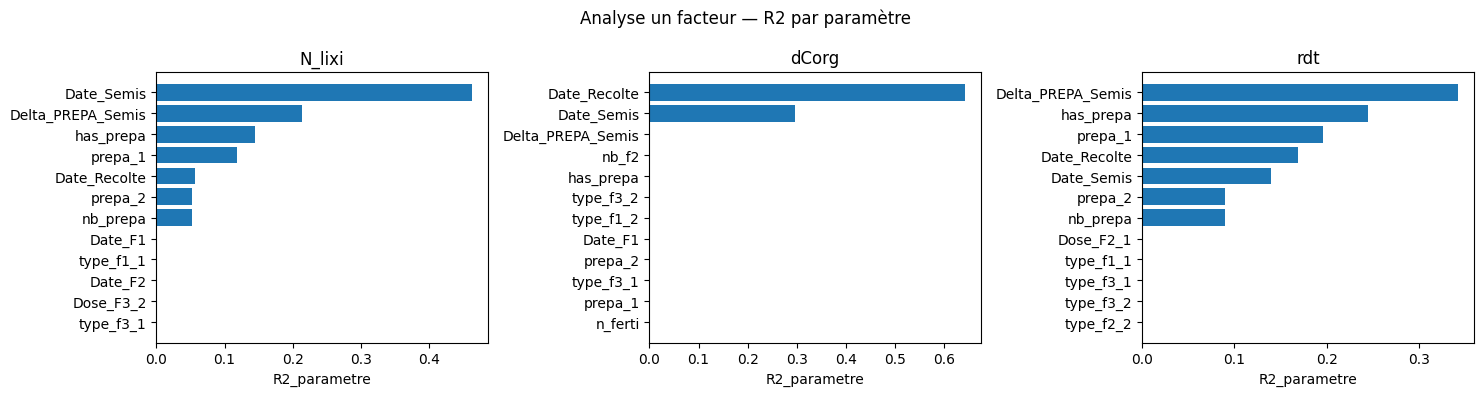

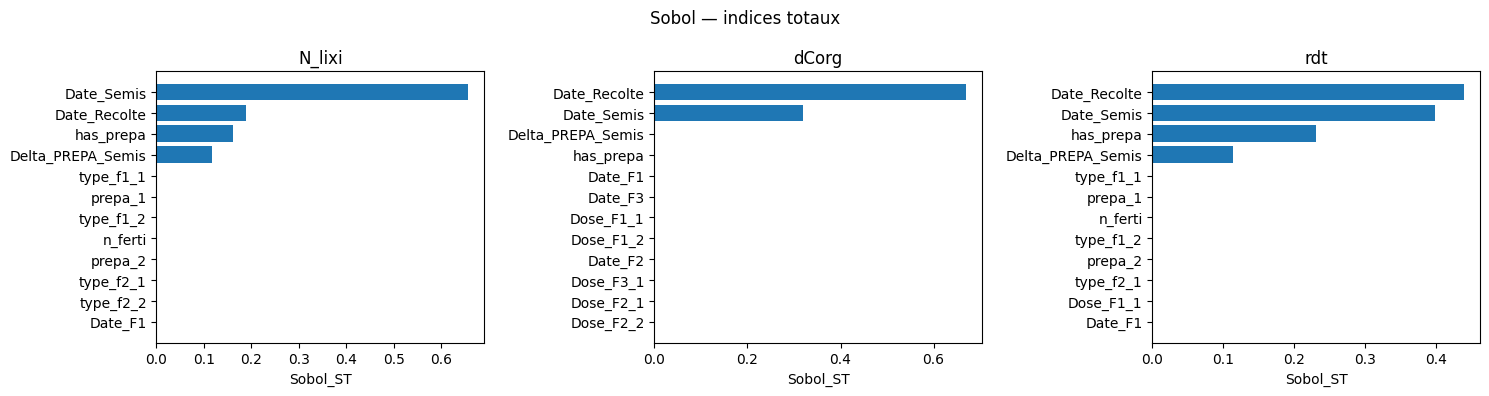

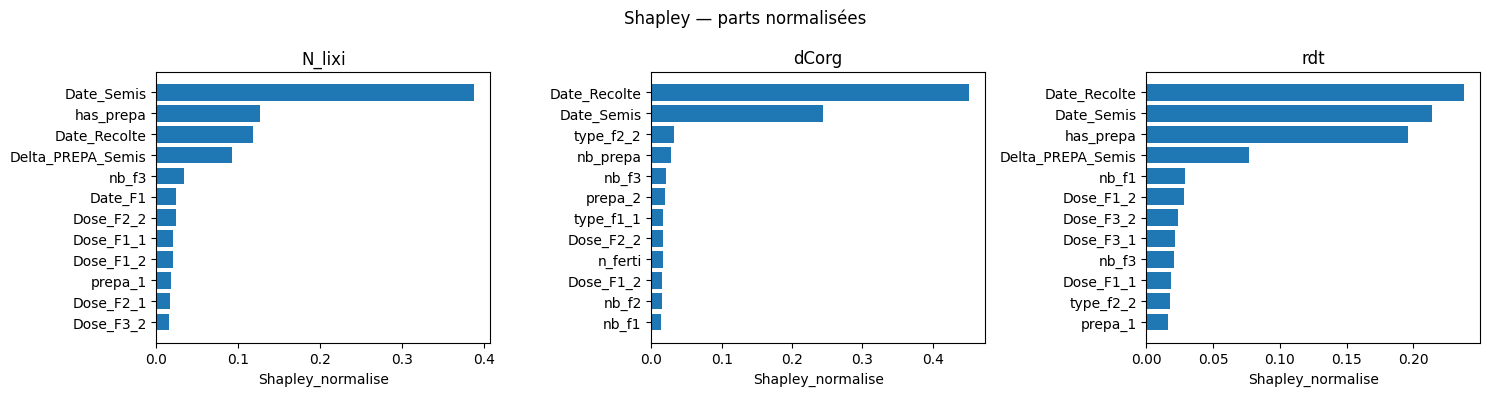

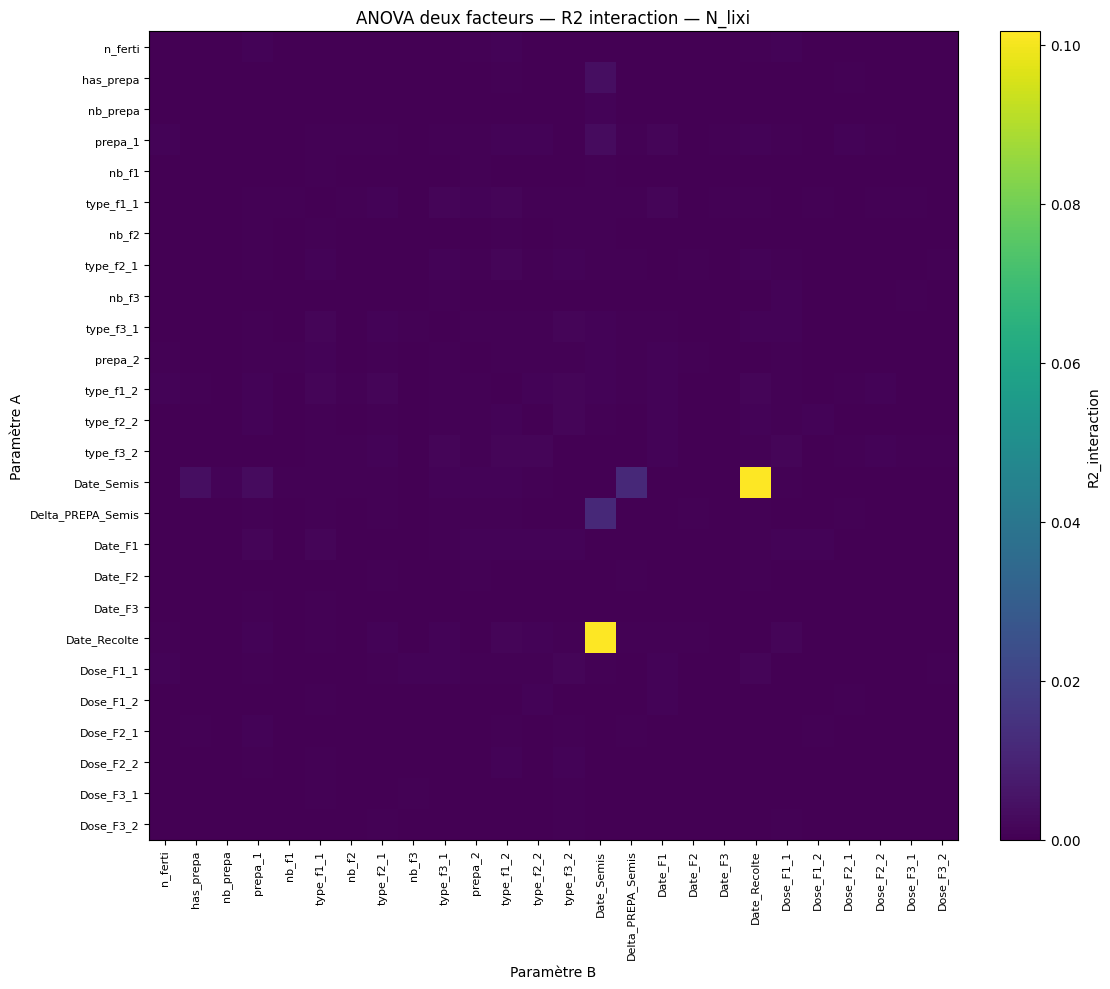

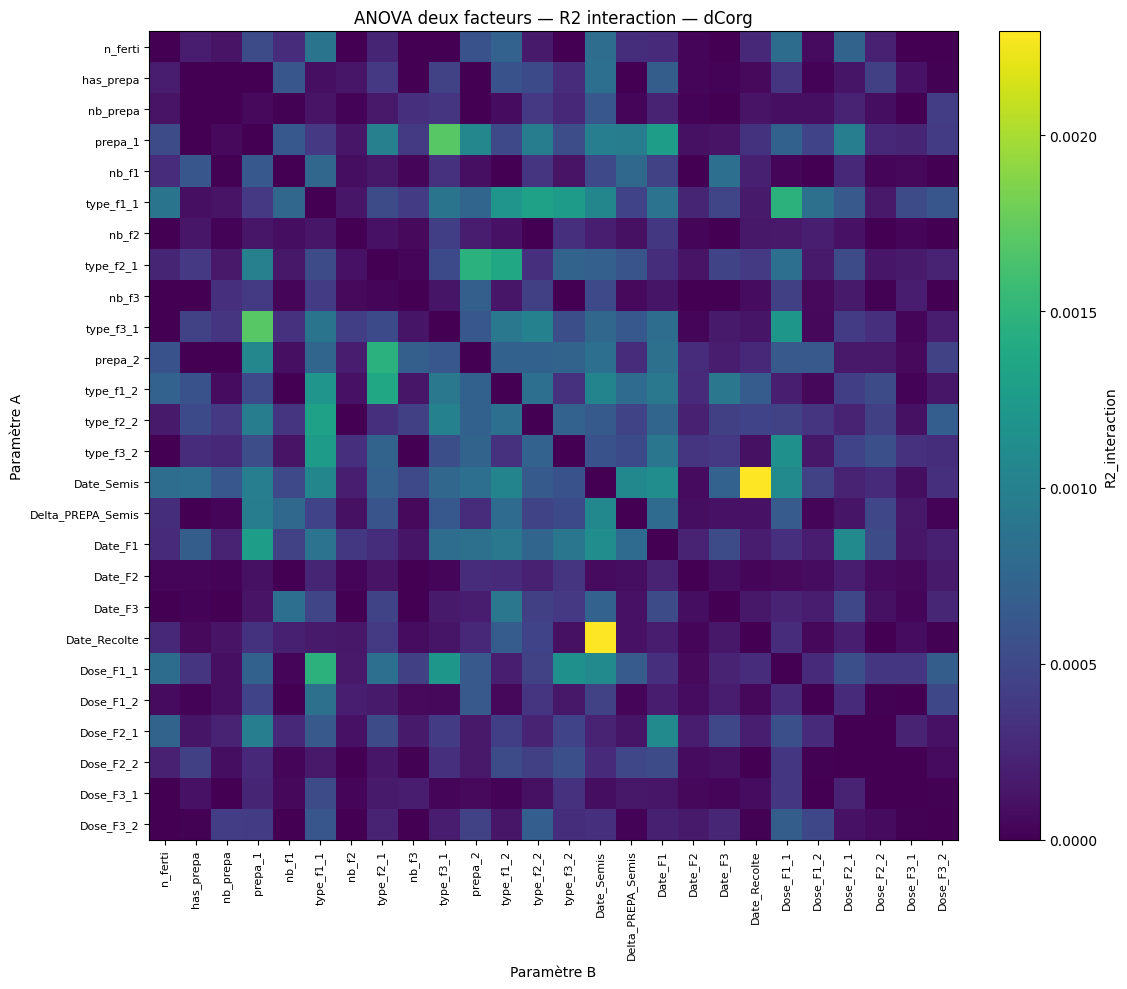

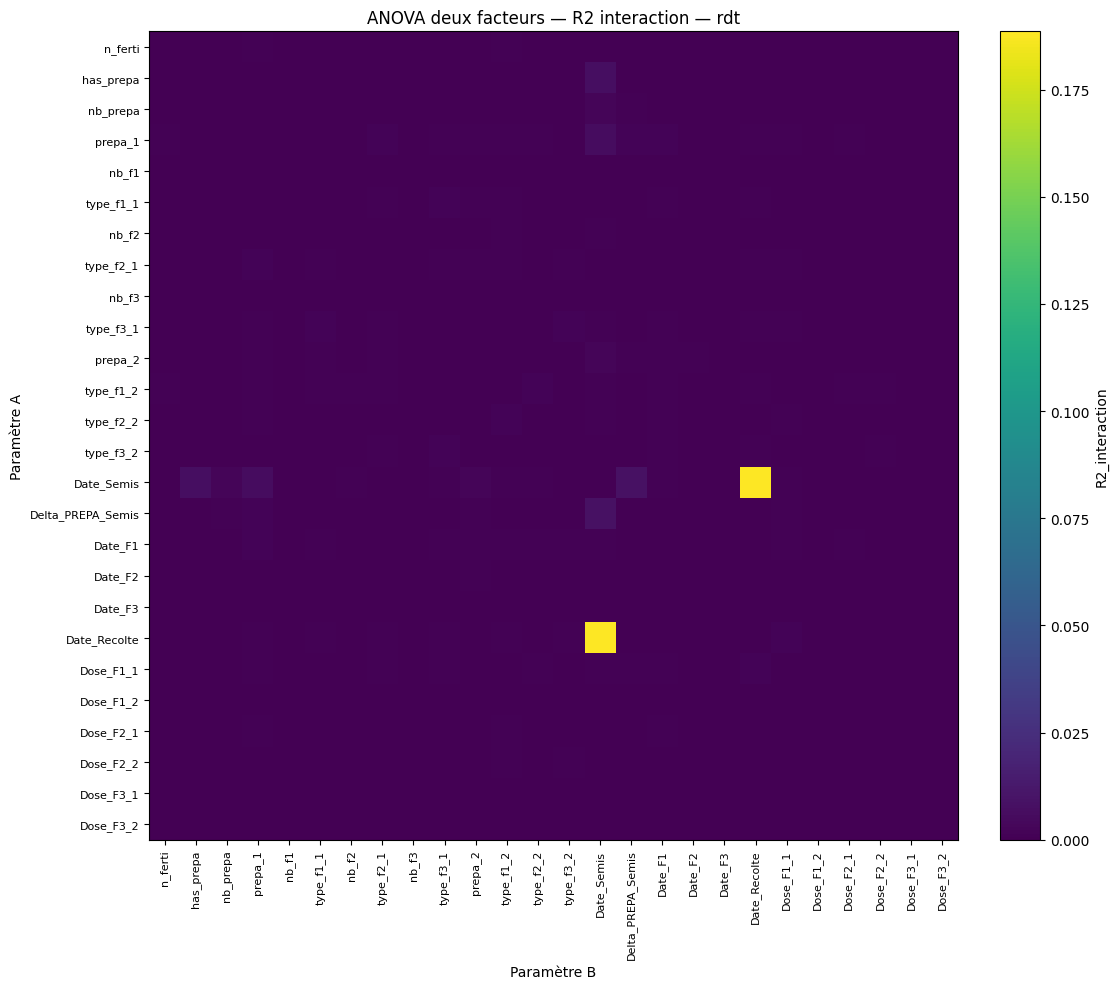

Figures écrites dans : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/terrainSA_results


In [22]:
# ============================================================
# 12. Figures de synthèse
# ============================================================

def plot_top(df_plot, value_col, title, filename, top_n=12):
    fig, axes = plt.subplots(1, len(OUTPUT_COLS), figsize=(5 * len(OUTPUT_COLS), 4), sharex=False)
    if len(OUTPUT_COLS) == 1:
        axes = [axes]
    for ax, output in zip(axes, OUTPUT_COLS):
        sub = (
            df_plot[df_plot["sortie"] == output]
            .sort_values(value_col, ascending=False)
            .head(top_n)
            .iloc[::-1]
        )
        ax.barh(sub["parametre"], sub[value_col])
        ax.set_title(output)
        ax.set_xlabel(value_col)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

def plot_anova_matrix_heatmap(output, value_col, title, filename, vmax=None):
    matrix = anova_2_matrices[(output, value_col)].copy()
    matrix = matrix.reindex(index=AGRI_FEATURES, columns=AGRI_FEATURES)
    masked = np.ma.masked_invalid(matrix.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(masked, cmap="viridis", vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(AGRI_FEATURES)))
    ax.set_yticks(np.arange(len(AGRI_FEATURES)))
    ax.set_xticklabels(AGRI_FEATURES, rotation=90, fontsize=8)
    ax.set_yticklabels(AGRI_FEATURES, fontsize=8)
    ax.set_xlabel("Paramètre B")
    ax.set_ylabel("Paramètre A")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(value_col)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=180)
    plt.show()

def plot_all_anova_heatmaps():
    for output in OUTPUT_COLS:
        plot_anova_matrix_heatmap(
            output=output,
            value_col="R2_interaction",
            title=f"ANOVA deux facteurs — R2 interaction — {output}",
            filename=f"heatmap_anova_2facteurs_R2_interaction_{output}.png",
            vmax=None,
        )

plot_top(anova_1, "R2_parametre", "Analyse un facteur — R2 par paramètre", "anova_1facteur_top.png")
plot_top(sobol_df, "Sobol_ST", "Sobol PCE — indices totaux analytiques", "sobol_total_top.png")
plot_top(shapley_df, "Shapley_normalise", "Shapley — parts normalisées", "shapley_top.png")
plot_all_anova_heatmaps()

print("Figures écrites dans :", OUTPUT_DIR)


## À lire avant interprétation

- `terrainSA` fixe volontairement le sol et le climat ; les indices portent donc sur les opérations techniques uniquement.
- Les tests ANOVA/Kruskal à un facteur sont directs et descriptifs sur les sorties MAELIA.
- Les analyses à deux facteurs utilisent des facteurs discrétisés et rapportent surtout les R2 globaux et d'interaction.
- Le plan SMT/ADSG n'est pas un plan Saltelli : les recombinaisons libres de colonnes peuvent créer des points non faisables.
- Les indices de Sobol principaux du notebook sont donc estimés analytiquement à partir d'un PCE creux entraîné sur les points faisables observés.
- Les paramètres catégoriels restent plus délicats à interpréter dans un PCE numérique ; les conclusions les plus robustes portent surtout sur les paramètres temporels et continus.
- Le Gaussian Process est entraîné sur un sous-échantillon (`GP_SMT_MAX_TRAIN` ou `GP_MAX_TRAIN`) pour rester calculable.
- Les indices empiriques pick-freeze et les valeurs de Shapley via métamodèle sont conservés comme diagnostics complémentaires, pas comme preuve formelle de Sobol sur un plan Saltelli.
- Si le `Q2_test` du PCE ou du meilleur métamodèle reste faible pour une sortie, les indices associés doivent être considérés comme exploratoires.
